# 📊 Sales Data Analysis & Business Insights

## Data Storytelling & Final Project

This project analyzes sales data to discover important trends, patterns, and business insights.

The purpose of this project is to transform raw sales data into meaningful information that can help a business understand its sales performance and make data-driven decisions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving sales_data (1).csv to sales_data (1).csv


In [4]:
df = pd.read_csv("sales_data (1).csv")

df.head()

,Month,Category,Product,UnitsSold,Price,Revenue
0,2025-01,Electronics,Wireless Earbuds,58,111.14,6446.12
1,2025-01,Electronics,Smartphone Case,47,91.81,4315.07
2,2025-01,Electronics,Power Bank,46,13.42,617.32
3,2025-01,Electronics,Bluetooth Speaker,46,130.60,6007.60
4,2025-01,Clothing,T-Shirt,57,7.98,454.86


In [5]:
df.shape

(240, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Month      240 non-null    object 
 1   Category   240 non-null    object 
 2   Product    240 non-null    object 
 3   UnitsSold  240 non-null    int64  
 4   Price      240 non-null    float64
 5   Revenue    240 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 11.4+ KB


In [7]:
df.isnull().sum()

,0
Month,0
Category,0
Product,0
UnitsSold,0
Price,0
Revenue,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,UnitsSold,Price,Revenue
count,240.000000,240.000000,240.000000
mean,35.704167,79.940750,2874.694000
std,14.113111,44.302468,1960.694025
min,0.000000,5.730000,0.000000
25%,26.000000,44.065000,1198.920000
50%,34.000000,83.900000,2703.570000
75%,44.000000,121.507500,4048.650000
max,86.000000,148.560000,8419.950000


## 2. Dataset Overview

Before starting the analysis, the dataset was inspected to understand its structure, size, data types, missing values, and duplicate records.

The dataset contains 240 sales records and 6 columns. The main variables include month, product category, product, units sold, price, and revenue.

This initial inspection helps ensure that the dataset is properly understood and prepared for further analysis.



In [10]:
df.dtypes

,0
Month,object
Category,object
Product,object
UnitsSold,int64
Price,float64
Revenue,float64


In [11]:
(df["Revenue"] < 0).sum()

np.int64(0)

## 3. Data Cleaning

The dataset was checked for missing values, duplicate records, data types, and invalid revenue values.

No missing values or duplicate records were found in the dataset. The numerical columns were also checked to ensure that they contain valid numerical data.

Since the dataset was already clean and properly structured, no records were removed or modified unnecessarily.

The cleaned dataset is now ready for exploratory data analysis.



In [12]:
total_revenue = df["Revenue"].sum()
total_revenue

np.float64(689926.56)

In [13]:
total_units = df["UnitsSold"].sum()
total_units

np.int64(8569)

In [14]:
average_revenue = df["Revenue"].mean()
average_revenue

np.float64(2874.6940000000004)

In [15]:
print("Total Revenue:", total_revenue)
print("Total Units Sold:", total_units)
print("Average Revenue per Record:", average_revenue)

Total Revenue: 689926.56
Total Units Sold: 8569
Average Revenue per Record: 2874.6940000000004


## 4. Overall Sales Performance

To understand the overall performance of the business, key sales metrics were calculated from the dataset.

The analysis focuses on three important indicators:

* **Total Revenue:** The overall revenue generated from the recorded sales.
* **Total Units Sold:** The total number of products sold.
* **Average Revenue per Record:** The average revenue generated across the sales records.

These metrics provide a high-level overview of the business performance before analyzing individual months, categories, and products.



In [16]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue

,Revenue
Month,
2025-01,47092.28
2025-02,48259.05
2025-03,64411.54
2025-04,41623.48
2025-05,62515.25
2025-06,63917.73
2025-07,68984.29
2025-08,43683.71
2025-09,65897.49


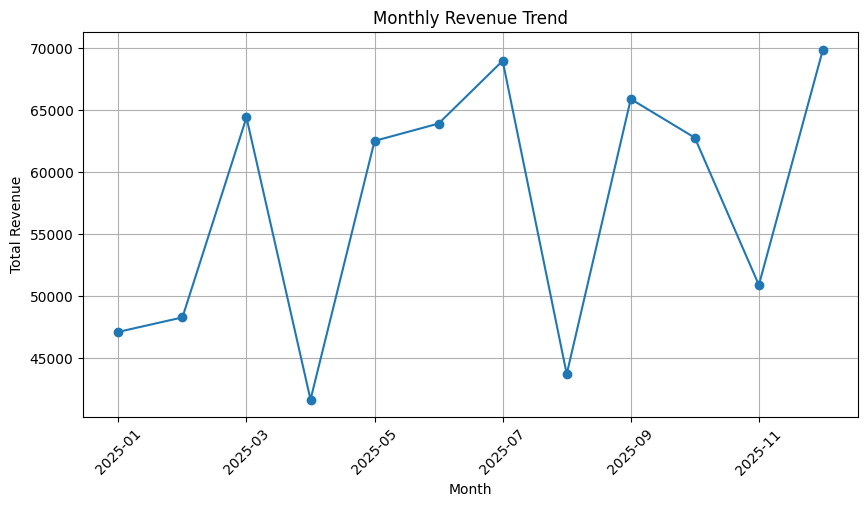

In [17]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 5. Monthly Revenue Analysis

The monthly revenue trend shows how the business performed throughout the year.

Revenue fluctuates significantly across different months rather than following a consistent pattern. The highest revenue is recorded in December, at nearly 70,000, while July also shows strong performance with revenue close to 69,000.

The lowest revenue occurs in April, with revenue of approximately 41,500. A noticeable drop can also be seen in August after the strong performance in July.

### Key Finding

The business experiences considerable month-to-month variation in revenue. This suggests that customer demand and sales performance may change throughout the year.

### Business Implication

The business can monitor the factors behind high-performing months and use these insights when planning inventory, promotions, and marketing activities for future months.


In [18]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

category_revenue

,Revenue
Category,
Electronics,203591.92
Clothing,140973.07
Beauty,131380.90
Home & Kitchen,126777.87
Books,87202.80


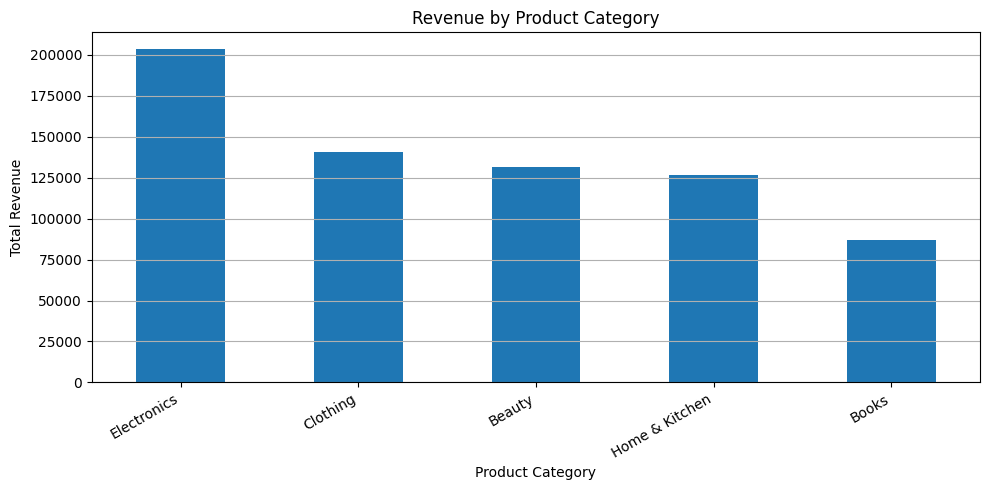

In [19]:
plt.figure(figsize=(10,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 6. Revenue by Product Category

The category-wise analysis shows that revenue varies considerably across different product categories.

**Electronics** generates the highest total revenue, reaching approximately **204,000**. **Clothing** is the second-highest revenue-generating category, followed by **Beauty** and **Home & Kitchen**.

**Books** generates the lowest total revenue, at approximately **88,000**.

### Key Finding

Electronics is the strongest revenue-generating category in the dataset, while Books contributes comparatively less revenue.

### Business Implication

The business can continue monitoring high-performing categories such as Electronics and Clothing while investigating the reasons behind the lower revenue of Books.

Factors such as customer demand, pricing, product variety, and marketing activity could be analyzed further to understand these differences.


In [20]:
product_revenue = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

product_revenue

,Revenue
Product,
Wireless Earbuds,56318.41
Bluetooth Speaker,50076.43
Smartphone Case,48900.65
Power Bank,48296.43
Sneakers,40784.69
Jeans,40682.04
Cookware Set,40442.54
Perfume,35759.90
Face Cream,34145.16


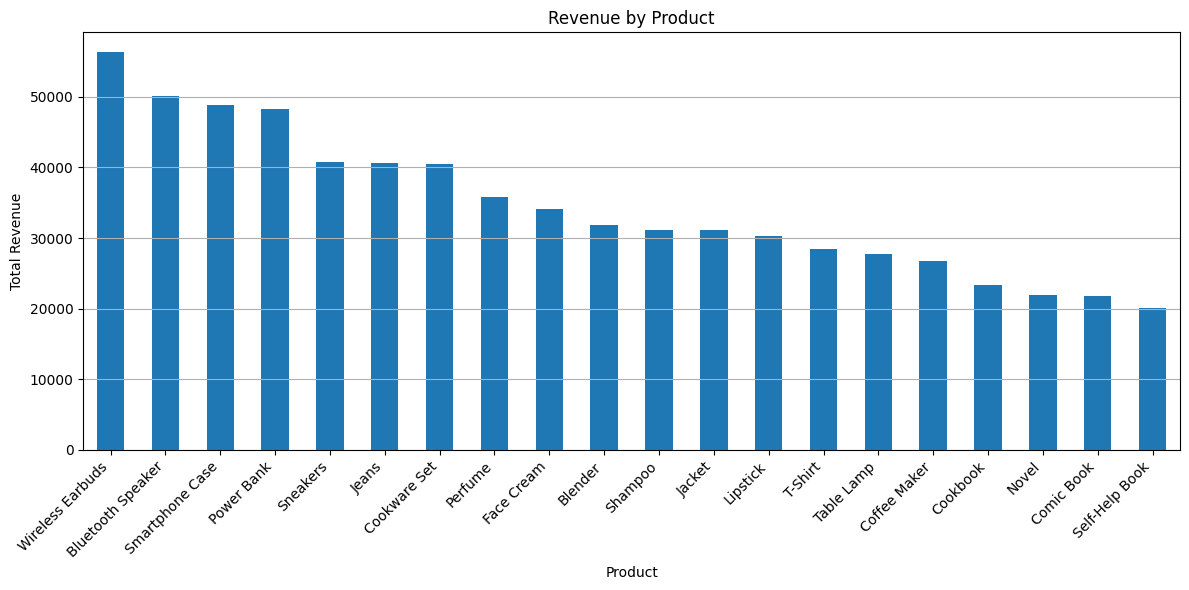

In [21]:
plt.figure(figsize=(12,6))

product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 7. Product-wise Revenue Analysis

The product-wise analysis shows that revenue performance varies considerably across individual products.

**Wireless Earbuds** generate the highest revenue, with approximately **56,000** in total revenue. Bluetooth Speaker is the second-highest revenue-generating product, followed by Smartphone Case and Power Bank.

At the lower end, **Self-Help Book** generates approximately **20,000**, making it the lowest revenue-generating product in the dataset.

### Key Finding

A small group of products contributes significantly more revenue than some other products. Wireless Earbuds are the strongest individual product based on total revenue.

### Business Implication

The business can closely monitor high-performing products to understand what drives their demand. Lower-performing products can be further evaluated based on customer demand, pricing, product variety, and marketing performance.

This analysis can help the business make more informed decisions about inventory planning and promotional activities.


In [22]:
category_units = df.groupby("Category")["UnitsSold"].sum().sort_values(ascending=False)

category_units

,UnitsSold
Category,
Electronics,2330
Clothing,1822
Beauty,1783
Home & Kitchen,1494
Books,1140


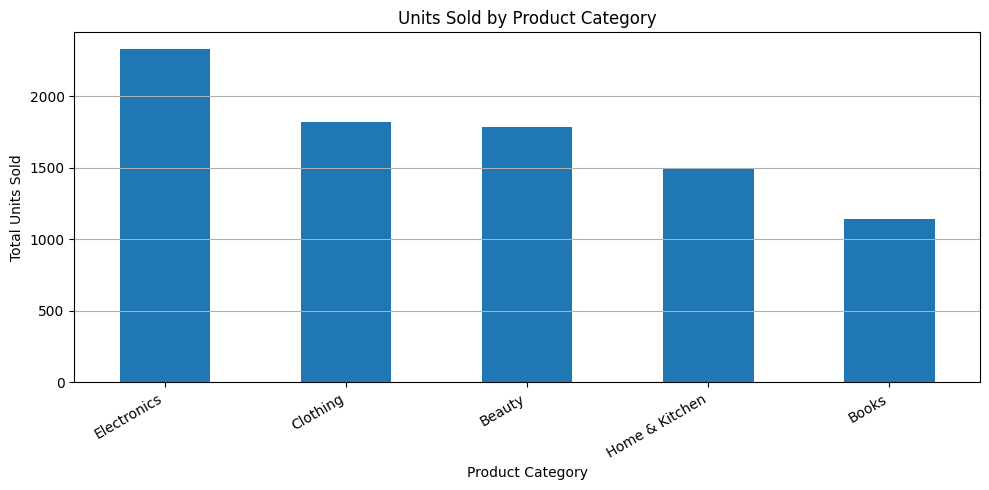

In [23]:
plt.figure(figsize=(10,5))

category_units.plot(kind="bar")

plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 8. Units Sold by Product Category

The units sold analysis shows the sales volume of each product category.

**Electronics** has the highest number of units sold, with approximately **2,300 units**. Clothing and Beauty follow with around 1,800 and 1,750 units respectively.

**Books** has the lowest sales volume, with approximately **1,150 units**.

### Key Finding

Electronics performs strongly in both revenue and sales volume, while Books has the lowest performance in terms of units sold.

### Business Implication

The strong sales volume of Electronics indicates high customer demand in this category. The business can continue monitoring this category and ensure that popular products remain available.

For lower-volume categories such as Books, the business can investigate customer demand, pricing, product selection, and promotional strategies to identify possible improvement opportunities.

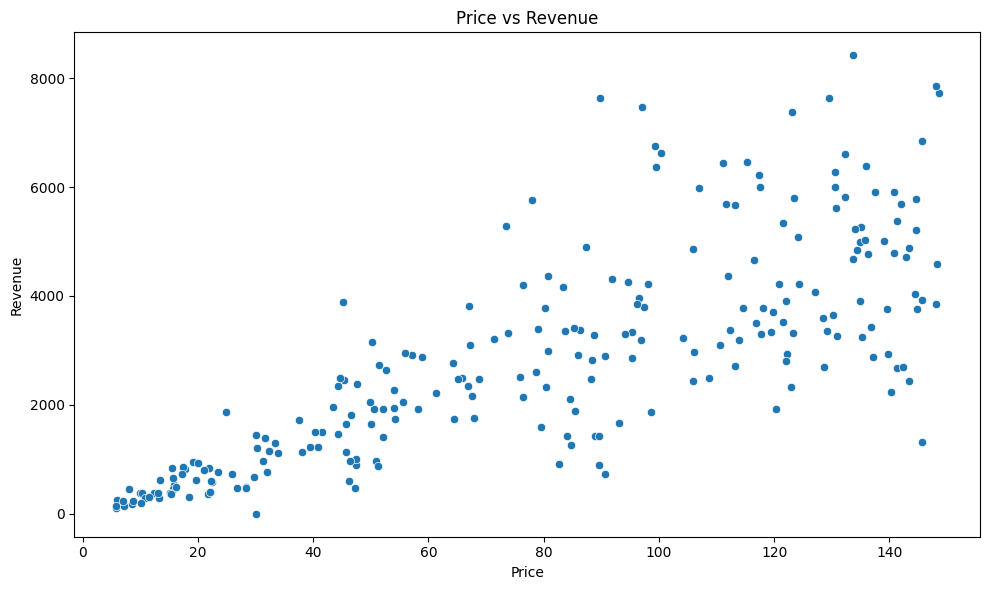

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="Price", y="Revenue")

plt.title("Price vs Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [25]:
correlation = df["Price"].corr(df["Revenue"])
correlation

np.float64(0.78216590619574)

## 9. Price and Revenue Relationship

To understand whether product price is associated with revenue, a scatter plot was created and the correlation between Price and Revenue was calculated.

The correlation coefficient is approximately **0.78**, which indicates a strong positive relationship between price and revenue in this dataset.

### Key Finding

The analysis suggests that higher-priced products tend to be associated with higher revenue values. However, price is not the only factor affecting revenue because the number of units sold also contributes to total revenue.

### Business Implication

The business should consider both **product pricing and sales volume** when evaluating revenue performance. Products with higher prices can generate substantial revenue, but maintaining sufficient sales volume is also important.

In [26]:
product_units = df.groupby("Product")["UnitsSold"].sum().sort_values(ascending=False)

product_units

,UnitsSold
Product,
Wireless Earbuds,660
Power Bank,584
Smartphone Case,567
Bluetooth Speaker,519
Sneakers,495
Shampoo,485
Face Cream,469
Jeans,467
Perfume,443


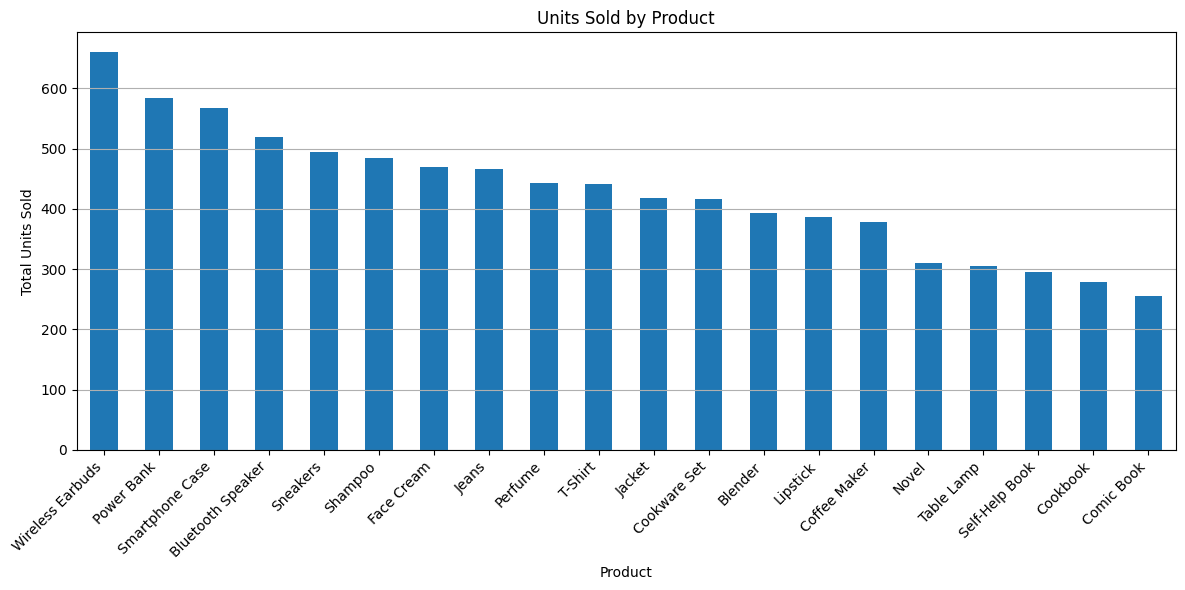

In [27]:
plt.figure(figsize=(12,6))

product_units.plot(kind="bar")

plt.title("Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Top Products by Units Sold

The analysis shows that **Wireless Earbuds** have the highest sales volume, with more than **600 units sold**. This indicates strong customer demand for the product and suggests that the business should maintain sufficient inventory to meet demand.


In [28]:
avg_price_category = df.groupby("Category")["Price"].mean().sort_values(ascending=False)

avg_price_category

,Price
Category,
Electronics,88.567500
Home & Kitchen,85.505833
Clothing,77.193958
Books,74.750625
Beauty,73.685833


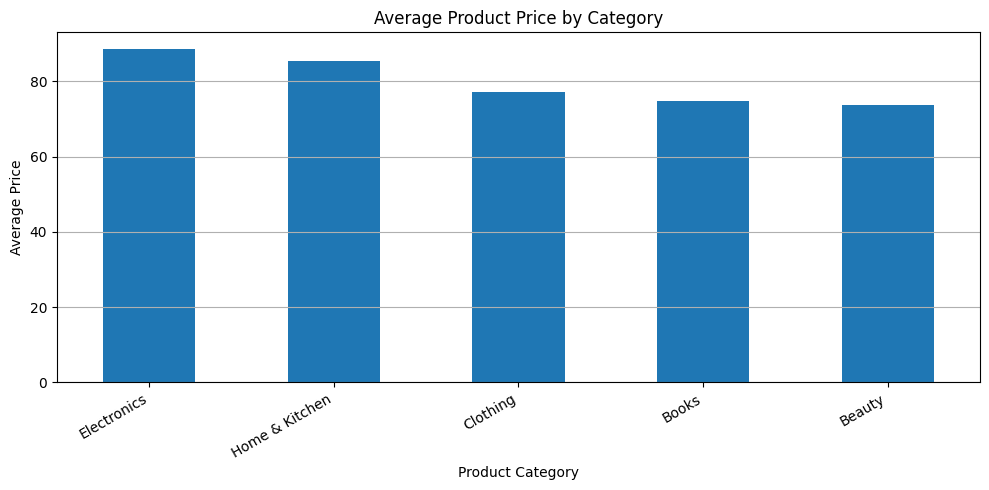

In [29]:
plt.figure(figsize=(10,5))

avg_price_category.plot(kind="bar")

plt.title("Average Product Price by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Price")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Average Price by Category

The analysis shows that **Electronics has the highest average product price, with an average price of more than 80**. This indicates that products in the Electronics category are generally priced higher than products in the other categories.


## 10. Key Findings

The analysis revealed several important patterns in the sales data:

1. Revenue varies across different months, showing changes in monthly sales performance.
2. December recorded the highest monthly revenue, while April recorded the lowest.
3. Electronics is the highest revenue-generating category.
4. Electronics also has the highest number of units sold.
5. Wireless Earbuds are the highest-selling product by units, with more than 600 units sold.
6. Electronics has the highest average product price, with an average price of more than 80.
7. Price and revenue show a strong positive relationship, with a correlation of approximately 0.78.

These findings provide a clear overview of the factors contributing to sales performance.


## 11. Business Recommendations

Based on the findings from the analysis, the following recommendations can be considered:

### 1. Focus on High-Performing Categories

Electronics generates the highest revenue and has a high sales volume. The business should continue monitoring demand in this category and maintain sufficient inventory of popular products.

### 2. Monitor High-Performing Products

Wireless Earbuds have the highest sales volume, with more than 600 units sold. The business can analyze why this product performs well and use similar strategies for other products.

### 3. Investigate Lower-Performing Products

Products with comparatively lower sales and revenue should be reviewed. The business can investigate factors such as pricing, customer demand, product variety, and marketing activity.

### 4. Plan Around Monthly Trends

Revenue changes from month to month. The business can use historical trends to plan inventory and marketing activities during periods of higher expected demand.

### 5. Consider Both Price and Sales Volume

Revenue performance depends on both product price and the number of units sold. Therefore, pricing decisions should be evaluated together with sales volume rather than considering price alone.


## 12. Predictive Modeling

To demonstrate the predictive modeling process, a Linear Regression model was trained using product price and units sold as input features.

The model attempts to estimate revenue based on these variables.

Since revenue is mathematically related to price and units sold in sales data, this model should be interpreted as a demonstration of the machine learning workflow rather than an independent future-sales forecasting system.


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
X = df[["UnitsSold", "Price"]]
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 493.49244476319035
Mean Squared Error: 361404.3100472556
R² Score: 0.9087080368568594


### Model Evaluation

The Linear Regression model achieved an **R² Score of approximately 0.91**, indicating that the model explains around 91% of the variation in revenue in the test data.

The model produced a **Mean Absolute Error (MAE) of approximately 493.49**, meaning that the average absolute difference between the actual and predicted revenue values is about 493.49 units of revenue.

The **Mean Squared Error (MSE) was approximately 361,404.31**. Overall, the evaluation demonstrates a strong relationship between the selected input features and revenue.

However, since revenue is directly related to price and units sold in this dataset, these results should be interpreted as a demonstration of the machine learning workflow rather than evidence of independent future-sales forecasting performance.


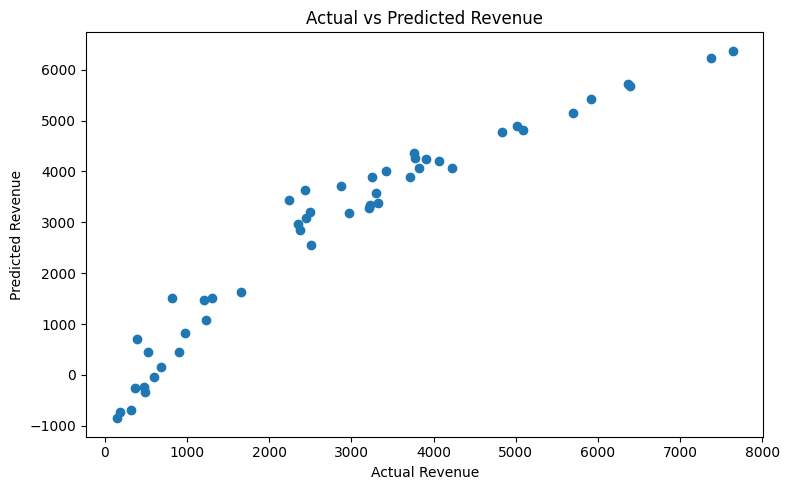

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.tight_layout()
plt.show()

## 13. Conclusion

This project demonstrates how sales data can be transformed into meaningful business insights using Python.

The analysis explored monthly revenue, category performance, product performance, sales volume, pricing, and the relationship between price and revenue.

The findings show that Electronics is a major contributor to revenue and sales volume, while Wireless Earbuds have the highest sales volume among the individual products.

The analysis also demonstrated a basic predictive modeling workflow using Linear Regression. The model achieved an R² Score of approximately 0.91 on the test data.

Overall, this project shows that data analysis is not only about writing code and creating visualizations. The real value comes from using data to identify patterns, communicate findings clearly, and support better business decisions.
